<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/dqn_cartpole_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical 10:** Introduction to Deep Reinforcement Learning

**Objective:** Understand reward functions and policy gradients by training an agent in a simulated environment.

**Dataset/Environment:** OpenAI Gymnasium (CartPole-v1)

**Course Outcomes:** CO1, CO5  
**Institution:** NIELIT ROPAR

---

This notebook will guide you step-by-step to:
- Initialize the CartPole environment
- Implement a Deep Q-Network (DQN) agent with experience replay
- Train the agent to balance the pole
- Visualize the agent's learning progress via reward maximization

In [1]:
!pip install -q gymnasium

import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from collections import deque
import random
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Define the Deep Q-Network (DQN) Agent

In [2]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)  # Experience replay buffer
        self.gamma = 0.95    # Discount rate for future rewards
        self.epsilon = 1.0   # Initial exploration rate (100% random actions)
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        # Neural Net for Deep-Q learning Model
        model = models.Sequential([
            layers.Dense(24, input_dim=self.state_size, activation='relu'),
            layers.Dense(24, activation='relu'),
            layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        # Epsilon-greedy policy
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])  # returns action with highest Q-value

    def replay(self, batch_size):
        # Vectorized experience replay for faster Colab training
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)

        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])

        states = np.squeeze(states)
        next_states = np.squeeze(next_states)

        # Q-Learning update rule
        targets = rewards + self.gamma * (np.amax(self.model.predict_on_batch(next_states), axis=1)) * (1 - dones)
        targets_full = self.model.predict_on_batch(states)

        ind = np.array([i for i in range(batch_size)])
        targets_full[[ind], [actions]] = targets

        self.model.fit(states, targets_full, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

## Initialize Environment and Train

In [4]:
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = int(env.action_space.n)
agent = DQNAgent(state_size, action_size)

EPISODES = 100
batch_size = 32
scores = []

print("Starting training...")
for e in range(EPISODES):
    # Reset environment and get initial state
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])

    for time in range(500): # CartPole max steps is 500
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        reward = reward if not done else -10 # Penalize for failing

        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state

        if done:
            print(f"Episode: {e+1}/{EPISODES}, Score: {time}, Epsilon: {agent.epsilon:.2f}")
            scores.append(time)
            break

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)

env.close()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Episode: 1/100, Score: 41, Epsilon: 0.96
Episode: 2/100, Score: 16, Epsilon: 0.88
Episode: 3/100, Score: 13, Epsilon: 0.83
Episode: 4/100, Score: 30, Epsilon: 0.71
Episode: 5/100, Score: 13, Epsilon: 0.67
Episode: 6/100, Score: 21, Epsilon: 0.60
Episode: 7/100, Score: 11, Epsilon: 0.57
Episode: 8/100, Score: 18, Epsilon: 0.52
Episode: 9/100, Score: 9, Epsilon: 0.50
Episode: 10/100, Score: 11, Epsilon: 0.47
Episode: 11/100, Score: 13, Epsilon: 0.44
Episode: 12/100, Score: 13, Epsilon: 0.41
Episode: 13/100, Score: 9, Epsilon: 0.39
Episode: 14/100, Score: 12, Epsilon: 0.37
Episode: 15/100, Score: 8, Epsilon: 0.36
Episode: 16/100, Score: 10, Epsilon: 0.34
Episode: 17/100, Score: 18, Epsilon: 0.31
Episode: 18/100, Score: 39, Epsilon: 0.25
Episode: 19/100, Score: 26, Epsilon: 0.22
Episode: 20/100, Score: 28, Epsilon: 0.19
Episode: 21/100, Score: 13, Epsilon: 0.18
Episode: 22/100, Score: 18, Epsilon: 0.17
Episode: 23/100, Score: 23, Epsilon: 0.15
Episode: 24/100, Score: 1

## Visualize Cumulative Reward
Instead of rendering the physical cart in Colab (which requires virtual displays), we track the agent's intelligence by graphing how long it managed to keep the pole balanced over time.

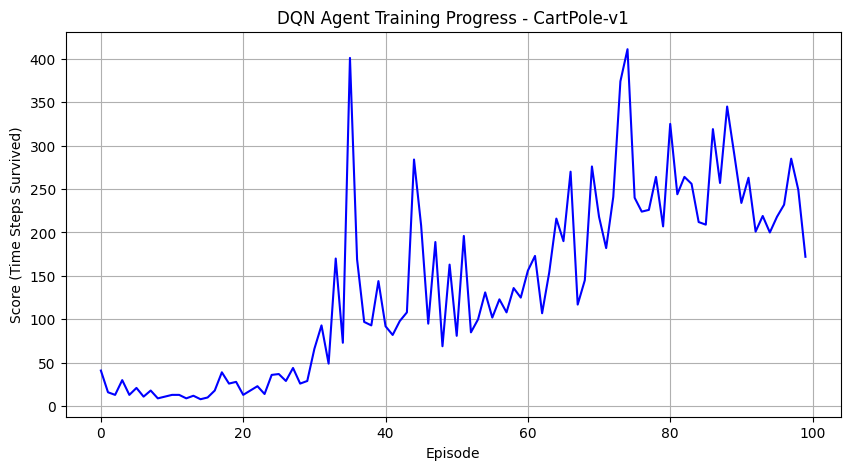

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(scores, color='blue')
plt.title('DQN Agent Training Progress - CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Score (Time Steps Survived)')
plt.grid(True)
plt.show()